## 0. Iris flower dataset (\*)

In the whole exercise, we will work with the famous Iris flower dataset, which was collected in 1936 by Ronald Fisher, a statistician and biologist. Use the `datasets` module from scikit-learn to load the iris dataset.

&nbsp; a) Check keys on the loaded data and check what the different values for each key are.

&nbsp; b) Now insert the data into a DataFrame.

&nbsp; c) Do some EDA to get an understanding of the dataset.

&nbsp; d) Make a correlation heatmap to see how each feature is correlated to each other. What do the numbers mean?

&nbsp; e) Make a boxplot. The points outside of the boxplot are statistically calculated outliers using Tukey's rule for boxplot.

&nbsp; f) Now remove the outliers in data. (\*\*)

- Lower bound outlier: $Q_1 - 1.5\cdot IQR$
- Upper bound outlier: $Q_3 + 1.5\cdot IQR$

where $Q_1$ is the 1st quartile or 25 percentile, $Q_3$ is the 3rd quartile or 75 percentile and $IQR = Q_3-Q_1$ is the interquartile range.

&nbsp; g) Do train|test split on the dataset and then scale it with feature standardization.

&nbsp; h) Classify using logistic regression

&nbsp; i) Classify the first 10 values of your $X_{test}$ and compare it manually with your labels.

&nbsp; j) Evaluate your model using classification report and confusion matrix. 

### Use the `datasets` module from scikit-learn to load the iris dataset.

In [1]:
from sklearn.datasets import load_iris

dataset = load_iris()

### a) Check keys on the loaded data and check what the different values for each key are.

In [2]:
# dataset keys = 'data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'
# 3 target names = 'setosa', 'versicolor', 'virginica'
# 4 feature names = 'sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'
# 50 rows for each target(150 total)

dataset.target_names
dataset.feature_names
dataset.keys()
print(dataset.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [3]:
help(load_iris)

Help on function load_iris in module sklearn.datasets._base:

load_iris(*, return_X_y=False, as_frame=False)
    Load and return the iris dataset (classification).

    The iris dataset is a classic and very easy multi-class classification
    dataset.

    =================   ==============
    Classes                          3
    Samples per class               50
    Samples total                  150
    Dimensionality                   4
    Features            real, positive
    =================   ==============

    Read more in the :ref:`User Guide <iris_dataset>`.

    .. versionchanged:: 0.20
        Fixed two wrong data points according to Fisher's paper.
        The new version is the same as in R, but not as in the UCI
        Machine Learning Repository.

    Parameters
    ----------
    return_X_y : bool, default=False
        If True, returns ``(data, target)`` instead of a Bunch object. See
        below for more information about the `data` and `target` object.

 

### b) Insert the data into a DataFrame.

In [4]:
# example 1 (directly from load_iris function)
data = load_iris(as_frame=True)
data.frame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [5]:
# example 2 (straight to X and y)
X, y = load_iris(as_frame=True, return_X_y=True)
X, y

(     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 0                  5.1               3.5                1.4               0.2
 1                  4.9               3.0                1.4               0.2
 2                  4.7               3.2                1.3               0.2
 3                  4.6               3.1                1.5               0.2
 4                  5.0               3.6                1.4               0.2
 ..                 ...               ...                ...               ...
 145                6.7               3.0                5.2               2.3
 146                6.3               2.5                5.0               1.9
 147                6.5               3.0                5.2               2.0
 148                6.2               3.4                5.4               2.3
 149                5.9               3.0                5.1               1.8
 
 [150 rows x 4 columns],
 0      0
 1      0
 2   

In [6]:
# example 3 (manually creating dataframe from the loaded dataset)
import pandas as pd

# iris - 0=setosa, 1=versicolour, 2=virginica

df = pd.DataFrame(dataset["data"], columns=dataset["feature_names"])

df["target"] = dataset["target"]
df['target_name'] = pd.Categorical.from_codes(dataset.target, dataset.target_names)

df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


### c) Do some EDA to get an understanding of the dataset.

In [7]:
# when testing the algorithm with some fae data -< get a sense of the ranges that we can use
# when validating input data
df.describe().T.drop("count", axis=1)

,mean,std,min,25%,50%,75%,max
sepal length (cm),5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


In [8]:
# balanced dataset
df["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [9]:
df.shape, df.columns, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   target             150 non-null    int64   
 5   target_name        150 non-null    category
dtypes: category(1), float64(4), int64(1)
memory usage: 6.3 KB


((150, 6),
 Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
        'petal width (cm)', 'target', 'target_name'],
       dtype='object'),
 None)

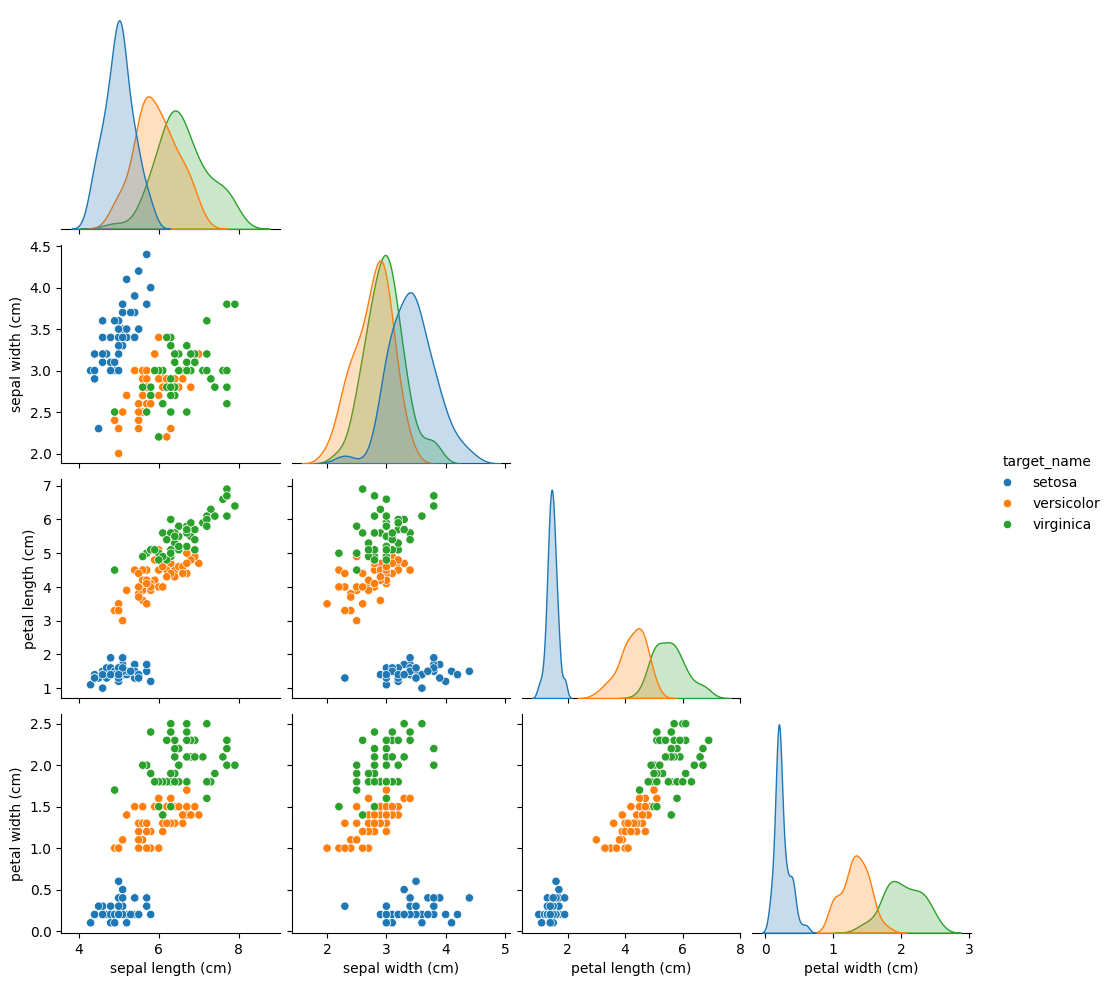

In [10]:
import seaborn as sns

# setosa clearly has higher length than the others, but slightly less sepal width
sns.pairplot(df.drop("target", axis=1), corner=True, hue="target_name", diag_kind="kde")

### d) Make a correlation heatmap to see how each feature is correlated to each other. What do the numbers mean?

<Axes: >

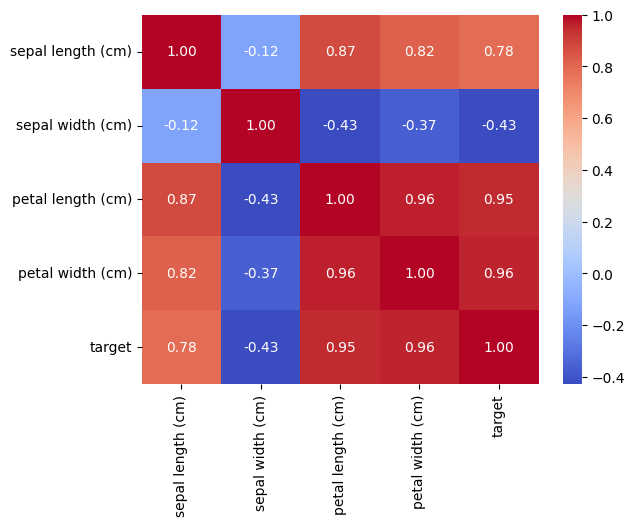

In [27]:
# petal length vs petal width = strong positive correlation (0.92)
# sepal length vs sepal width = weak negative correlation (-0.12)
# petal measurements are strongly related
# and sepal width is less correlated with other features
sns.heatmap(df.drop(["target_name"], axis=1).corr(), annot=True, cmap="coolwarm", fmt=".2f")

### e) Make a boxplot. The points outside of the boxplot are statistically calculated outliers using Tukey's rule for boxplot.

<Axes: >

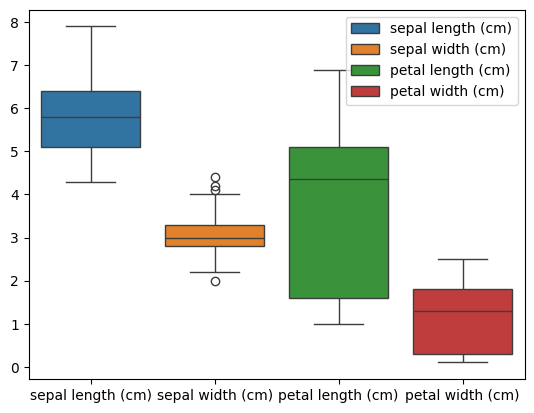

In [12]:
# only sepal width has outliers
sns.boxplot(df.drop("target", axis=1), legend=True)

Now remove the outliers in data. (\*\*)

- Lower bound outlier: $Q_1 - 1.5\cdot IQR$
- Upper bound outlier: $Q_3 + 1.5\cdot IQR$

where $Q_1$ is the 1st quartile or 25 percentile, $Q_3$ is the 3rd quartile or 75 percentile and $IQR = Q_3-Q_1$ is the interquartile range.

In [ ]:
df["sepal width (cm)"].describe().T
# 25% = 2.8
# Q1 = df["sepal width (cm)"].quantile(.25)
# Q3 = df["sepal width (cm)"].quantile(.75)
# 75% = 3.3

Q1 = 2.8
Q3 = 3.3
IQR = Q3-Q1

lower_bound_outlier = Q1-1.5*IQR
upper_bound_outlier = Q3+1.5*IQR

# outliers är värden under 2.05 och över 4.05
lower_bound_outlier, upper_bound_outlier

(2.05, 4.05)

In [14]:
df_no_outliers = df[(df["sepal width (cm)"] >= lower_bound_outlier) & (df["sepal width (cm)"] <= upper_bound_outlier)]
# tog bort 4 rader/värden
df_no_outliers.shape, df.shape

((146, 6), (150, 6))

### g) Do train|test split on the dataset and then scale it with feature standardization.

Encoding

In [15]:
# target behövs inte? kör bara på target_name
dummy_df = pd.get_dummies(df_no_outliers.drop("target", axis=1), drop_first=True)*1
dummy_df

# eller så behövs bara target, och vi kan skippa target_name och skippa encoding

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target_name_versicolor,target_name_virginica
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,0,0
2,4.7,3.2,1.3,0.2,0,0
3,4.6,3.1,1.5,0.2,0,0
4,5.0,3.6,1.4,0.2,0,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0,1
146,6.3,2.5,5.0,1.9,0,1
147,6.5,3.0,5.2,2.0,0,1
148,6.2,3.4,5.4,2.3,0,1


In [16]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


train|test split

In [17]:
# Do train|test split on the dataset
from sklearn.model_selection import train_test_split

# split features and targets into X and y
X, y = df_no_outliers[df_no_outliers.columns[:4]], df_no_outliers["target"]
X, y

# split X and y into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.shape, X_test.shape

((97, 4), (49, 4))

In [18]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 146, dtype: int64

In [19]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Scaling

In [20]:
# scale it with feature standardization.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

print(f"{scaled_X_train.mean() = }")
print(f"{scaled_X_train.std() = }")
print(f"{scaled_X_test.mean() = }")
print(f"{scaled_X_test.std() = }")

scaled_X_train.mean() = np.float64(4.944498418949151e-16)
scaled_X_train.std() = np.float64(0.9999999999999997)
scaled_X_test.mean() = np.float64(-0.026200181679167572)
scaled_X_test.std() = np.float64(0.9999349444958893)


### h) Classify using logistic regression

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(scaled_X_train, y_train)

y_pred = model.predict(scaled_X_test)
y_pred_proba = model.predict_proba(scaled_X_test)

### i) Classify the first 10 values of your $X_{test}$ and compare it manually with your labels.

In [22]:
# 1 fel
y_pred[:10] - y_test[:10]

48     0
101    0
28     0
20     0
45     0
124    0
30     0
84     0
70     1
19     0
Name: target, dtype: int64

### j) Evaluate your model using classification report and confusion matrix. 

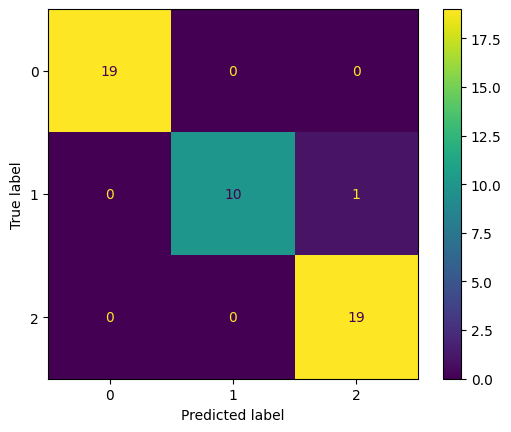

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
# only 1 error

In [24]:
y_test.shape, y_pred.shape

((49,), (49,))

In [25]:
print(classification_report(y_test, y_pred))
# good 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.91      0.95        11
           2       0.95      1.00      0.97        19

    accuracy                           0.98        49
   macro avg       0.98      0.97      0.98        49
weighted avg       0.98      0.98      0.98        49

